In [36]:
# %pip install simple-icd-10 --quiet

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
import simple_icd_10 as icd
from pickle import dump, load

In [38]:
MODEL = "deepseek-ai_DeepSeek-V3_max"
with open(f"embeddings/{MODEL}.pkl", "rb") as f: embeddings = load(f)['deepseek-ai/DeepSeek-V3']
embeddings = {k : v.float().numpy() for k, v in embeddings.items()}
df = pd.DataFrame({"icd10_category": list(embeddings.keys()), "cls": list(embeddings.values())})

In [39]:
df.head()

,icd10_category,cls
0,A01,"[0.067871094, 0.071777344, 0.05029297, 0.03955..."
1,A02,"[0.016967773, 0.025878906, 0.017333984, 0.0375..."
2,A03,"[0.018920898, 0.07763672, 0.048339844, 0.02648..."
3,A04,"[0.016967773, 0.025878906, 0.017333984, 0.0375..."
4,A05,"[0.03515625, 0.04736328, 0.041992188, 0.016845..."


In [40]:
df["is_category"] = df["icd10_category"].apply(icd.is_category)
df = df[df["is_category"]]
df["parent"] = df["icd10_category"].apply(icd.get_parent)
df["chapter"] = df["parent"].apply(icd.get_parent)
df["is_chapter"] = df["chapter"].apply(icd.is_chapter)
df.loc[~df['is_chapter'], 'chapter'] = df.loc[~df['is_chapter'], 'chapter'].apply(icd.get_parent)
df["is_chapter"] = df["chapter"].apply(icd.is_chapter)
df.loc[~df['is_chapter'], 'chapter'] = df.loc[~df['is_chapter'], 'chapter'].apply(icd.get_parent)

In [41]:
df

,icd10_category,cls,is_category,parent,chapter,is_chapter
0,A01,"[0.067871094, 0.071777344, 0.05029297, 0.03955...",True,A00-A09,I,True
1,A02,"[0.016967773, 0.025878906, 0.017333984, 0.0375...",True,A00-A09,I,True
2,A03,"[0.018920898, 0.07763672, 0.048339844, 0.02648...",True,A00-A09,I,True
3,A04,"[0.016967773, 0.025878906, 0.017333984, 0.0375...",True,A00-A09,I,True
4,A05,"[0.03515625, 0.04736328, 0.041992188, 0.016845...",True,A00-A09,I,True
...,...,...,...,...,...,...
1752,Z95,"[0.008544922, 0.05102539, 0.04736328, 0.016845...",True,Z80-Z99,XXI,True
1753,Z96,"[0.008544922, 0.056884766, 0.05419922, 0.01684...",True,Z80-Z99,XXI,True
1754,Z97,"[0.029418945, 0.05102539, 0.041503906, 0.02978...",True,Z80-Z99,XXI,True
1755,Z98,"[0.016967773, 0.07421875, 0.0546875, 0.0317382...",True,Z80-Z99,XXI,True


In [42]:
df["description"] = df["chapter"].apply(icd.get_description)
df = df.sort_values(by='chapter')

/tmp/ipykernel_888057/410798532.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout(rect=[0, 0, 0.85, 1])


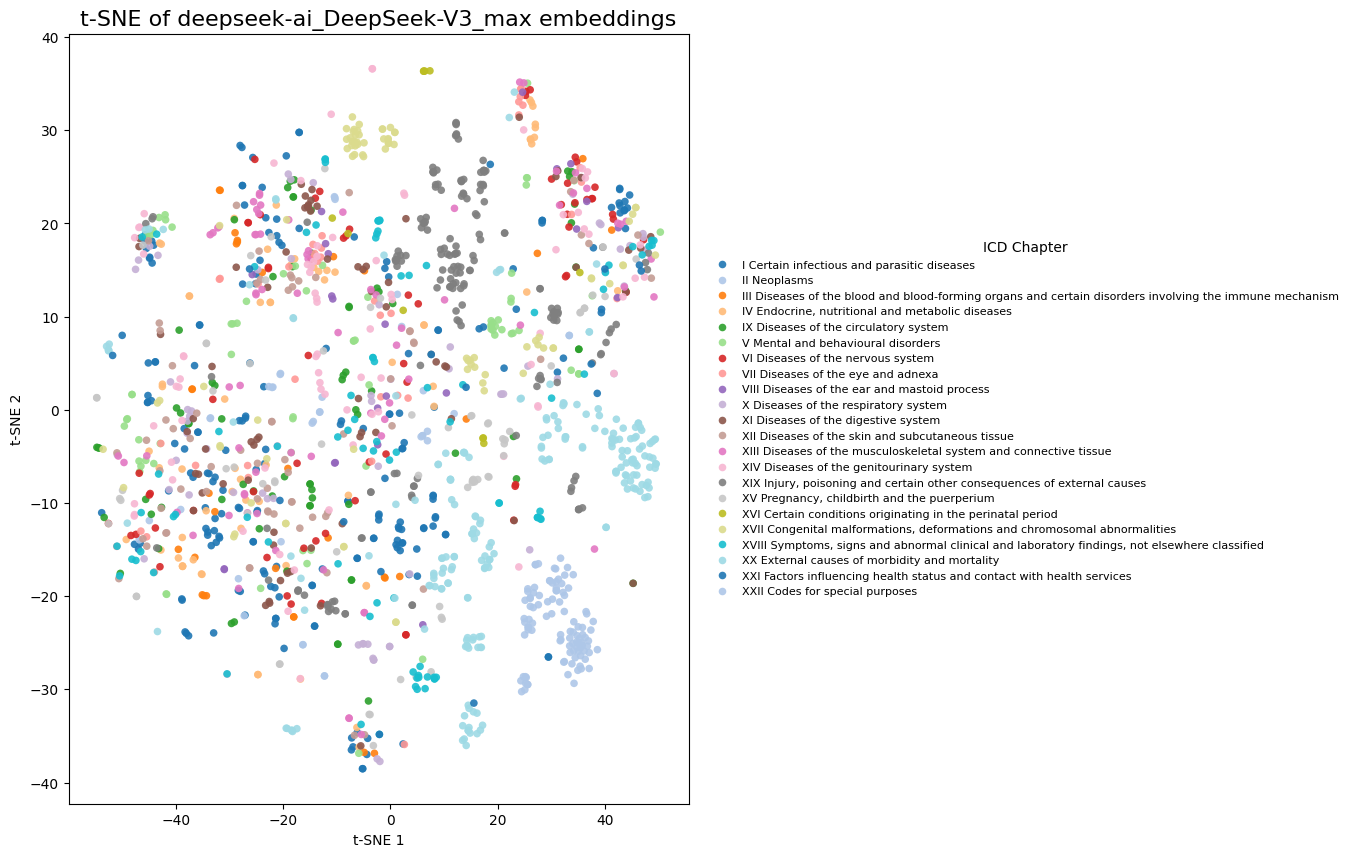

In [43]:
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns

embeddings = np.vstack(df['cls'].values)

df['group'] = df['chapter'] + " " + df['description']

tsne = TSNE(n_components=2, random_state=42, perplexity=40)
tsne_results = tsne.fit_transform(embeddings)

df['tsne_1'] = tsne_results[:, 0]
df['tsne_2'] = tsne_results[:, 1]

plt.figure(figsize=(8, 10))
sns.scatterplot(
    x='tsne_1', y='tsne_2',
    hue='group',
    palette='tab20',
    data=df,
    s=30,
    alpha=0.9,
    linewidth=0
)

plt.title(f"t-SNE of {MODEL} embeddings", fontsize=16)
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")

plt.legend(
    title="ICD Chapter",
    bbox_to_anchor=(1.02, 0.5), 
    loc='center left',  
    fontsize=8,
    title_fontsize='medium',
    ncol=1,
    frameon=False
)

plt.tight_layout(rect=[0, 0, 0.85, 1]) 
if not os.path.exists("pics"):
    os.makedirs("pics")
plt.savefig(f"pics/{MODEL}_tsne.png", dpi=100, bbox_inches='tight')
plt.show()